In [12]:
#Étape 0 : importation

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.optimizers.schedules import CosineDecay
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

np.random.seed(42)
tf.random.set_seed(42)

In [13]:
#Étape 1 : chargement dataset
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

print("X_train_full :", X_train_full.shape)
print("y_train_full :", y_train_full.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)
print("Classes :", np.unique(y_train_full))

X_train_full : (60000, 28, 28)
y_train_full : (60000,)
X_test : (10000, 28, 28)
y_test : (10000,)
Classes : [0 1 2 3 4 5 6 7 8 9]


In [14]:
#Étape 2 : prétraitement
# Conversion en float
X_train_full = X_train_full.astype("float32")
X_test = X_test.astype("float32")

# Normalisation simple [0,255] → [0,1]
X_train_full = X_train_full / 255.0
X_test = X_test / 255.0

# Flatten : 28x28 → 784
X_train_full = X_train_full.reshape(X_train_full.shape[0], 28 * 28)
X_test = X_test.reshape(X_test.shape[0], 28 * 28)

print("Après flatten :")
print("X_train_full :", X_train_full.shape)
print("X_test :", X_test.shape)

Après flatten :
X_train_full : (60000, 784)
X_test : (10000, 784)


In [15]:
#Étape 3 : split train / validation
X_train_base, X_val_base, y_train_base, y_val_base = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    stratify=y_train_full,
    random_state=42
)

print("X_train_base :", X_train_base.shape)
print("X_val_base :", X_val_base.shape)

X_train_base : (48000, 784)
X_val_base : (12000, 784)


In [16]:
#Étape 4 : standardisation
scaler_base = StandardScaler()

X_train_base_scaled = scaler_base.fit_transform(X_train_base)
X_val_base_scaled = scaler_base.transform(X_val_base)
X_test_base_scaled = scaler_base.transform(X_test)

In [17]:
#Étape 5 : fonction modèle
def build_model(input_dim, hidden_layers=(128,),
                activation="relu", optimizer_name="adam",
                learning_rate=0.001, use_cosine=False,
                steps_per_epoch=None, epochs=None):

    model = Sequential()
    model.add(Input(shape=(input_dim,)))

    for units in hidden_layers:
        model.add(Dense(units, activation=activation))

    model.add(Dense(10, activation="softmax"))

    if use_cosine:
        lr = CosineDecay(
            initial_learning_rate=learning_rate,
            decay_steps=steps_per_epoch * epochs,
            alpha=0.1
        )
    else:
        lr = learning_rate

    if optimizer_name == "adam":
        optimizer = Adam(learning_rate=lr)
    else:
        optimizer = SGD(learning_rate=lr)

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [18]:
#Fonction évaluation
def evaluate_model(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro")
    rec = recall_score(y_true, y_pred, average="macro")

    print(f"\n=== {model_name} ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision_macro : {prec:.4f}")
    print(f"Recall_macro : {rec:.4f}")
    print("\nClassification report :")
    print(classification_report(y_true, y_pred))

    return acc, prec, rec

In [19]:
#EarlyStopping
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=7,
    min_delta=0.001,
    restore_best_weights=True
)

**Q2 — BASELINE LR FIXE**

In [20]:
#Étape 6 : Partie A
baseline_fixed = build_model(
    input_dim=X_train_base_scaled.shape[1],
    hidden_layers=(128,),
    activation="relu",
    optimizer_name="adam",
    learning_rate=0.001,
    use_cosine=False
)

history_fixed = baseline_fixed.fit(
    X_train_base_scaled, y_train_base,
    validation_data=(X_val_base_scaled, y_val_base),
    epochs=25,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

y_pred_fixed = np.argmax(
    baseline_fixed.predict(X_test_base_scaled, verbose=0),
    axis=1
)

fixed_acc, fixed_prec, fixed_rec = evaluate_model(
    y_test, y_pred_fixed, "Baseline LR fixe"
)

Epoch 1/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8306 - loss: 0.4778 - val_accuracy: 0.8680 - val_loss: 0.3736
Epoch 2/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8748 - loss: 0.3445 - val_accuracy: 0.8773 - val_loss: 0.3509
Epoch 3/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8903 - loss: 0.3004 - val_accuracy: 0.8831 - val_loss: 0.3421
Epoch 4/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9006 - loss: 0.2698 - val_accuracy: 0.8855 - val_loss: 0.3366
Epoch 5/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9106 - loss: 0.2469 - val_accuracy: 0.8857 - val_loss: 0.3382
Epoch 6/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9181 - loss: 0.2265 - val_accuracy: 0.8854 - val_loss: 0.3424
Epoch 7/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9250 - loss: 0.2087 - val_accuracy: 0.8880 - val_loss: 0.3463
Epoch 8/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9307 - loss: 0.1935 - val_accuracy: 0.

**ANALYSE :**
Le modèle baseline avec learning rate fixe obtient une accuracy de 0.8686, avec une precision_macro et recall_macro proches (≈0.87). L’apprentissage est correct, car l’accuracy augmente progressivement, mais la validation se stabilise autour de 0.888, avec une légère augmentation de la val_loss, ce qui indique un début de surapprentissage. Certaines classes sont bien reconnues (1, 8, 9), tandis que d’autres comme la classe 6 restent difficiles.


**Q3 — COSINE DECAY**

In [21]:
#Étape 7 : Partie B
steps_per_epoch = int(np.ceil(X_train_base_scaled.shape[0] / 128))

baseline_cosine = build_model(
    input_dim=X_train_base_scaled.shape[1],
    hidden_layers=(128,),
    activation="relu",
    optimizer_name="adam",
    learning_rate=0.001,
    use_cosine=True,
    steps_per_epoch=steps_per_epoch,
    epochs=25
)

history_cosine = baseline_cosine.fit(
    X_train_base_scaled, y_train_base,
    validation_data=(X_val_base_scaled, y_val_base),
    epochs=25,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

y_pred_cosine = np.argmax(
    baseline_cosine.predict(X_test_base_scaled, verbose=0),
    axis=1
)

cos_acc, cos_prec, cos_rec = evaluate_model(
    y_test, y_pred_cosine, "Baseline Cosine Decay"
)

Epoch 1/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8268 - loss: 0.4851 - val_accuracy: 0.8663 - val_loss: 0.3747
Epoch 2/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8744 - loss: 0.3453 - val_accuracy: 0.8755 - val_loss: 0.3481
Epoch 3/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8900 - loss: 0.3004 - val_accuracy: 0.8805 - val_loss: 0.3402
Epoch 4/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9014 - loss: 0.2713 - val_accuracy: 0.8844 - val_loss: 0.3321
Epoch 5/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9097 - loss: 0.2472 - val_accuracy: 0.8875 - val_loss: 0.3284
Epoch 6/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9175 - loss: 0.2273 - val_accuracy: 0.8888 - val_loss: 0.3273
Epoch 7/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9243 - loss: 0.2097 - val_accuracy: 0.8892 - val_loss: 0.3279
Epoch 8/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9303 - loss: 0.1946 - val_accuracy: 0.

**ANALYSE:**
Le modèle avec Cosine Decay obtient une accuracy de 0.8731, légèrement meilleure que le baseline. L’entraînement est plus stable et la validation reste mieux contrôlée. Les métriques globales (precision_macro, recall_macro) sont aussi améliorées. Cela montre que l’adaptation du learning rate permet une meilleure convergence et généralisation.

**Q4 — COMPARAISON**

In [22]:
#Étape 8 : Comparaison
comparison_baselines = pd.DataFrame({
    "Modèle": ["Baseline LR fixe", "Baseline Cosine Decay"],
    "Accuracy": [fixed_acc, cos_acc],
    "Precision_macro": [fixed_prec, cos_prec],
    "Recall_macro": [fixed_rec, cos_rec]
})

print(comparison_baselines)

                  Modèle  Accuracy  Precision_macro  Recall_macro
0       Baseline LR fixe    0.8686         0.869664        0.8686
1  Baseline Cosine Decay    0.8731         0.873643        0.8731


**ANALYSE :**
Le modèle avec Cosine Decay est meilleur que le baseline LR fixe (0.8731 vs 0.8686). L’amélioration est faible mais réelle, ce qui montre que le learning rate adaptatif améliore légèrement les performances et la stabilité du modèle.

**Q5.a — PARAM GRID**

In [24]:
#Étape 9 : Partie C
param_grid = [
    {"hidden_layers": (64,),
     "activation": "relu",
     "optimizer_name": "adam",
     "batch_size": 128,
     "epochs": 30,
     "learning_rate": 0.001},

    {
        "hidden_layers": (128,),
        "activation": "relu",
        "optimizer_name": "adam",
        "batch_size": 128,
        "epochs": 25,
        "learning_rate": 0.001
    },
    {
        "hidden_layers": (256, 128),
        "activation": "relu",
        "optimizer_name": "adam",
        "batch_size": 128,
        "epochs": 25,
        "learning_rate": 0.001
    },
    {
        "hidden_layers": (128, 64),
        "activation": "relu",
        "optimizer_name": "sgd",
        "batch_size": 64,
        "epochs": 30,
        "learning_rate": 0.01
    },
    {
        "hidden_layers": (256, 128, 64),
        "activation": "relu",
        "optimizer_name": "adam",
        "batch_size": 64,
        "epochs": 30,
        "learning_rate": 0.0005
    }
]

**Q5.b — CROSS VALIDATION**

In [25]:
#Étape 10 : StratifiedKFold
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

results = []

for params in param_grid:

    fold_accuracies = []
    fold_precisions = []
    fold_recalls = []

    for train_idx, val_idx in cv.split(X_train_full, y_train_full):

        X_tr = X_train_full[train_idx]
        X_val = X_train_full[val_idx]
        y_tr = y_train_full[train_idx]
        y_val = y_train_full[val_idx]

        scaler_cv = StandardScaler()
        X_tr_scaled = scaler_cv.fit_transform(X_tr)
        X_val_scaled = scaler_cv.transform(X_val)

        steps_per_epoch_cv = int(np.ceil(X_tr_scaled.shape[0] / params["batch_size"]))

        model = build_model(
            input_dim=X_tr_scaled.shape[1],
            hidden_layers=params["hidden_layers"],
            activation=params["activation"],
            optimizer_name=params["optimizer_name"],
            learning_rate=params["learning_rate"],
            use_cosine=True,
            steps_per_epoch=steps_per_epoch_cv,
            epochs=params["epochs"]
        )

        early_stop_cv = EarlyStopping(
            monitor="val_loss",
            patience=2,
            restore_best_weights=True
        )

        model.fit(
            X_tr_scaled, y_tr,
            validation_data=(X_val_scaled, y_val),
            epochs=params["epochs"],
            batch_size=params["batch_size"],
            callbacks=[early_stop_cv],
            verbose=0
        )

        y_val_pred = np.argmax(model.predict(X_val_scaled, verbose=0), axis=1)

        acc = accuracy_score(y_val, y_val_pred)
        prec = precision_score(y_val, y_val_pred, average="macro")
        rec = recall_score(y_val, y_val_pred, average="macro")

        fold_accuracies.append(acc)
        fold_precisions.append(prec)
        fold_recalls.append(rec)

    results.append({
        "hidden_layers": params["hidden_layers"],
        "activation": params["activation"],
        "optimizer_name": params["optimizer_name"],
        "batch_size": params["batch_size"],
        "epochs": params["epochs"],
        "learning_rate": params["learning_rate"],
        "mean_cv_accuracy": np.mean(fold_accuracies),
        "mean_cv_precision": np.mean(fold_precisions),
        "mean_cv_recall": np.mean(fold_recalls),
        "std_cv_accuracy": np.std(fold_accuracies)
    })

In [26]:
#Étape 11 : Tab de resultat
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="mean_cv_accuracy", ascending=False).reset_index(drop=True)

print(results_df)

best_config = results_df.iloc[0]
print(best_config)

    hidden_layers activation optimizer_name  batch_size  epochs  \
0          (128,)       relu           adam         128      25   
1       (128, 64)       relu            sgd          64      30   
2      (256, 128)       relu           adam         128      25   
3  (256, 128, 64)       relu           adam          64      30   
4           (64,)       relu           adam         128      30   

   learning_rate  mean_cv_accuracy  mean_cv_precision  mean_cv_recall  \
0         0.0010          0.881717           0.881658        0.881717   
1         0.0100          0.880767           0.880349        0.880767   
2         0.0010          0.880183           0.881663        0.880183   
3         0.0005          0.880067           0.881310        0.880067   
4         0.0010          0.877917           0.877923        0.877917   

   std_cv_accuracy  
0         0.000125  
1         0.000798  
2         0.002607  
3         0.003450  
4         0.001473  
hidden_layers          (128,)
ac

**ANALYSE :**
Les résultats montrent que la meilleure configuration est :
(hidden_layers=(128,), optimizer=adam, batch_size=128, lr=0.001).
Elle obtient une accuracy moyenne ≈ 0.8817 avec une très faible variance, ce qui indique un modèle stable et performant.

**Q5.c — ENTRAINEMENT FINAL**

In [27]:
#Étape 12 : Bloc D

scaler_final = StandardScaler()
X_train_full_scaled = scaler_final.fit_transform(X_train_full)
X_test_scaled = scaler_final.transform(X_test)

best_hidden_layers = best_config["hidden_layers"]
best_activation = best_config["activation"]
best_optimizer_name = best_config["optimizer_name"]
best_batch_size = int(best_config["batch_size"])
best_epochs = int(best_config["epochs"])
best_learning_rate = float(best_config["learning_rate"])

steps_per_epoch_final = int(np.ceil(X_train_full_scaled.shape[0] / best_batch_size))

best_model = build_model(
    input_dim=X_train_full_scaled.shape[1],
    hidden_layers=best_hidden_layers,
    activation=best_activation,
    optimizer_name=best_optimizer_name,
    learning_rate=best_learning_rate,
    use_cosine=True,
    steps_per_epoch=steps_per_epoch_final,
    epochs=best_epochs
)

In [28]:
#Entrainement finale
early_stop_final = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_best = best_model.fit(
    X_train_full_scaled, y_train_full,
    validation_split=0.1,
    epochs=best_epochs,
    batch_size=best_batch_size,
    callbacks=[early_stop_final],
    verbose=1
)

Epoch 1/25
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8337 - loss: 0.4750 - val_accuracy: 0.8685 - val_loss: 0.3755
Epoch 2/25
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8785 - loss: 0.3379 - val_accuracy: 0.8765 - val_loss: 0.3472
Epoch 3/25
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8926 - loss: 0.2962 - val_accuracy: 0.8805 - val_loss: 0.3378
Epoch 4/25
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9033 - loss: 0.2666 - val_accuracy: 0.8822 - val_loss: 0.3348
Epoch 5/25
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9119 - loss: 0.2433 - val_accuracy: 0.8847 - val_loss: 0.3334
Epoch 6/25
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9202 - loss: 0.2231 - val_accuracy: 0.8842 - val_loss: 0.3343
Epoch 7/25
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9273 - loss: 0.2059 - val_accuracy: 0.8857 - val_loss: 0.3374
Epoch 8/25
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9333 - loss: 0.1900 - val_accuracy: 0.

In [29]:
#Évaluation finale
y_pred_best = np.argmax(best_model.predict(X_test_scaled, verbose=0), axis=1)

best_acc, best_prec, best_rec = evaluate_model(
    y_test, y_pred_best, "Meilleur modèle final"
)


=== Meilleur modèle final ===
Accuracy : 0.8767
Precision_macro : 0.8763
Recall_macro : 0.8767

Classification report :
              precision    recall  f1-score   support

           0       0.83      0.83      0.83      1000
           1       0.98      0.96      0.97      1000
           2       0.81      0.77      0.79      1000
           3       0.84      0.91      0.88      1000
           4       0.77      0.84      0.80      1000
           5       0.96      0.95      0.96      1000
           6       0.74      0.64      0.69      1000
           7       0.91      0.96      0.94      1000
           8       0.96      0.96      0.96      1000
           9       0.96      0.93      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



**ANALYSE :**

**a)**: On refait la standardisation car on utilise tout le dataset d’entraînement. Le scaler doit être recalculé pour refléter correctement les nouvelles données et éviter toute fuite d’information.

**b)**: Le meilleur modèle obtient une accuracy de 0.8767, avec precision_macro et recall_macro proches. Cela montre une amélioration par rapport aux deux baselines.

**c)**: Le modèle final est plus performant et plus robuste. La combinaison du tuning des hyperparamètres et de la validation croisée permet d’obtenir une meilleure généralisation.


**Q6 — COMPARAISON FINALE + MATRICE**

In [30]:
#Etape 13 : Comparaison finale
comparison_finale = pd.DataFrame({
    "Modèle": ["Baseline LR fixe", "Baseline Cosine Decay", "Best model manuel + CV"],
    "Accuracy": [fixed_acc, cos_acc, best_acc],
    "Precision_macro": [fixed_prec, cos_prec, best_prec],
    "Recall_macro": [fixed_rec, cos_rec, best_rec]
})

print(comparison_finale)

                   Modèle  Accuracy  Precision_macro  Recall_macro
0        Baseline LR fixe    0.8686         0.869664        0.8686
1   Baseline Cosine Decay    0.8731         0.873643        0.8731
2  Best model manuel + CV    0.8767         0.876342        0.8767


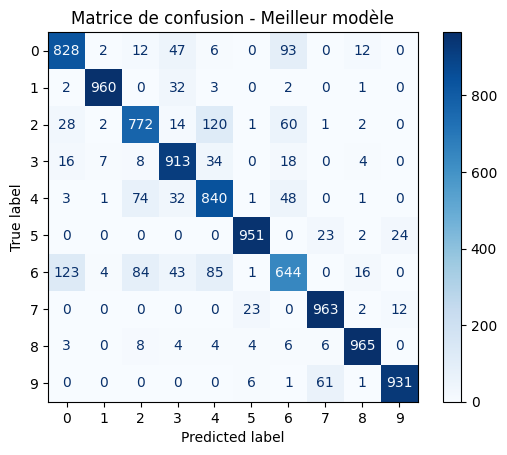

In [31]:
#Matrice de confusion
cm = confusion_matrix(y_test, y_pred_best)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format="d")

plt.title("Matrice de confusion - Meilleur modèle")
plt.show()

**ANALYSE :**

**a)**: Le modèle le plus performant est le Best model avec CV (0.8767), suivi du Cosine Decay (0.8731), puis du baseline (0.8686). L’amélioration vient du meilleur choix des hyperparamètres.

**b)**: L’amélioration est modérée mais significative. La validation croisée permet de choisir une configuration plus fiable et d’éviter un modèle biaisé par un seul split. Elle améliore donc la robustesse du modèle.

**c)**: Oui, la matrice montre une diagonale dominante, ce qui signifie que les prédictions sont globalement correctes. Cependant, certaines classes restent plus difficiles à distinguer.

**d)**:
 - Mieux reconnues : classes 1, 7, 8, 9
 - Plus confondues : classes 2, 4, 6

**e)**: Un exemple est la confusion entre classe 6 et classe 0 ou 4. Cela s’explique par des formes visuelles similaires des vêtements dans des images petites (28×28), ce qui rend la distinction difficile pour le modèle.

